# Week 2 - Polynomial Curve Fitting, Regularization and Cross-Validation

Learning contents:

1. Linear models
    - Linear function
    - Error function
    - Root mean square error
    - Optimization of Error function
    - Test the model
2. Regularization
    - Error function
    - Optimization
    - Test with regularization
3. Model Selection
    - Cross-validation
4. Bayesian curve fitting
    - Display results

## Description

In this exercise we will apply linear models to a polynomial curve fitting task.

You have to fill in the empty functions (with `pass` in the body) to match their purpose.

1. Write code for evaluating a linear model, computing its error functions, and finding the optimal weights that minimize a given error function.
2. Add regularization to the optimization procedure.
3. Implement the cross-validation model selection technique.
4. (Optional) Implement Bayesian curve fitting: first compute the phi and S matrices, then use them to compute the predictive mean and variance.

## Dependencies

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import  exp

import seaborn as sns; sns.set_theme(); sns.set_palette('bright')

## Generate Data

In [30]:
def target_func(x): return np.sin(2*np.pi*x)

def generate_data(size):
    rng = np.random.RandomState(26052605)
    x_train = rng.uniform(0., 1., size)
    y_train = target_func(x_train) + rng.normal(scale=0.1, size=size)
    x_test = np.linspace(0., 1., 100)
    y_test = target_func(x_test)
    
    return x_train, y_train, x_test, y_test

x_train, y_train, x_test, y_test = generate_data(10)

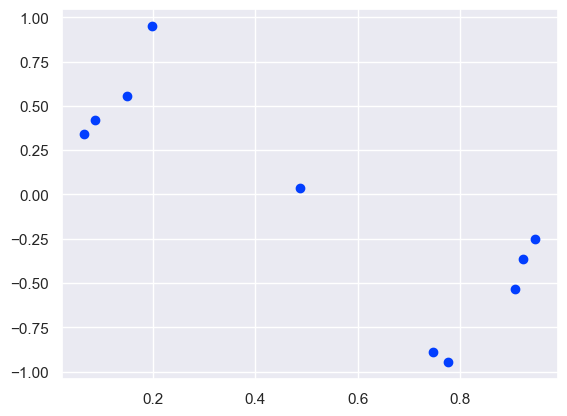

In [31]:
plt.scatter(x_train, y_train)

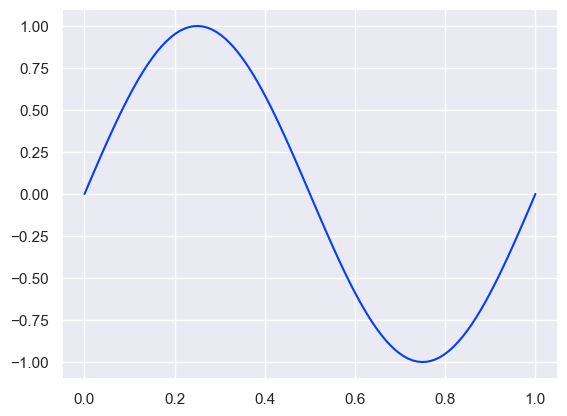

In [32]:
plt.plot(x_test, y_test, '-')

## 1) Linear models

### 1.1) Linear function

Complete the function below, named `linear`, which takes two parameters: a single data point `x` and a list of `M` number of `weights`. The function should return an output value `y` as given in the equation on slide 6 of Lecture 3. In essence, this function should implement a polynomial of order `M`.   

In [33]:
def linear(x, weights):
    powers = np.arange(len(weights)) # it creates [0, 1, ..., M-1], in order
    x_powers = np.power(x, powers) # it creates a vector of length M with x raised to the power of each entry in the power vector. Length = M
    dot_prod = np.dot(weights, x_powers)
    return dot_prod

### 1.2) Error function

Complete the function below, named `err`, that computes the sum-of-squared error between the output of the function above and the corresponding target value. Specifically, the function should implement the error equation in slide 7 of Lecture 3. The function takes `weights`, `inputs` and `targets` as parameters

In [34]:
def err(weights, inputs, targets):
    # 1) Usar la función linear para predecir cada elemento de inputs.
    x_preds = [] # crear una lista
    for x in inputs:
        prediction = linear(x, weights)
        x_preds.append(prediction)

    x_preds = np.array(x_preds)
    
    # 2) Calcular la diferencia entre cada predicción y su target, y elevar al cuadrado
    sqrd_diff = (x_preds - targets)**2
    # 3) Sumarlas y aplica el 1/2
    err_func = (1/2) * np.sum(sqrd_diff)
    return err_func

### 1.3) Root mean square error

Write a function for computing the root mean squared error as given in the equation in slide 12 of Lecture 3

In [35]:
def erms(weights, inputs, targets):
    err_func = err(weights, inputs, targets)
    erms_func = np.sqrt((2*err_func)/len(targets))
    return erms_func

### 1.4) Optimization of Error function

Create a function below that obtains `optimal_weights` by implementing the optimization solution given in slide 9 of Lecture 3. The function takes the following parameters: `inputs`, `targets`, and `M` (number of weights) as parameters and returns optimal weights for the given set of training data.

_Note on notation: Lecture 3 (slide 9) writes this solution with a design matrix $\mathbf{X}$ whose rows are $[1, x_n, x_n^2, \ldots, x_n^M]$. From Week 6 onward the same construction reappears under the name $\boldsymbol{\Phi}$ (general basis functions, Lecture 11) — polynomial fitting is the special case $\phi_j(x) = x^j$, so nothing changes but the symbol._

In [36]:
def optimal_weights(inputs, targets, M):
    shape_X = (len(inputs), M + 1) # this is the shape of the design matrix (N x M+1)
    X = np.vander(inputs, N=M + 1, increasing=True) # it produces the exact design matrix, increasing the powers after each element in the row
    p1 = np.linalg.inv(np.dot(np.transpose(X), X)) # (X^T X)^-1
    p2 = np.dot(p1, np.transpose(X))
    opt_weights = np.dot(p2, targets)
    return opt_weights

### 1.5) Test the model

Go through the following code and try to understand its functionality. After that, run the code and interpret the resulting figure.

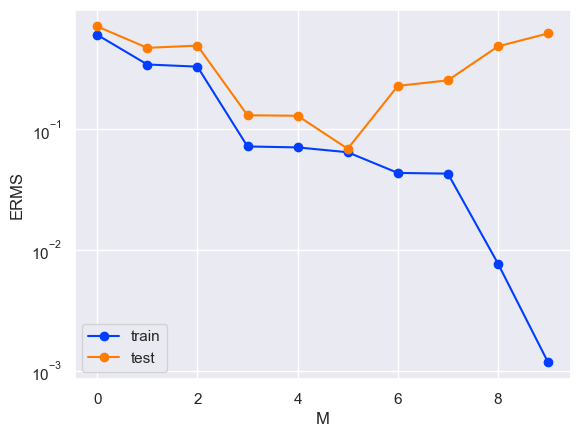

In [37]:
def test_all(start_M, end_M, x_train, y_train, x_test, y_test):
    
    results_train = []
    results_test = []
    all_weights = []
    
    for M in range(start_M, end_M + 1):
        weights = optimal_weights(x_train, y_train, M)
        all_weights.append(weights)
        error_train = erms(weights, x_train, y_train)
        error_test = erms(weights, x_test, y_test)
        results_train.append(error_train)
        results_test.append(error_test)
    return results_train, results_test, all_weights

r_tr, r_tt, all_weights = test_all(0, 9, x_train, y_train, x_test, y_test)

plt.plot(list(range(0, 10)), r_tr, '-o', label='train')
plt.plot(list(range(0, 10)), r_tt, '-o', label='test')
plt.xlabel('M')
plt.ylabel('ERMS')
plt.legend()
plt.yscale('log')

##### Weights table for different `M`

The following code lists the optimal weight vectors obtained for different model order `M` values. Explain what happens to the weights at large values of `M`.

*Expected observation:* weights grow rapidly (exponentially) in magnitude as M increases toward 9, while being small and smooth for low M. This is the overfitting signature discussed in L3 slide 14. Confirm this pattern in the table below before moving on.

In [38]:
print(pd.DataFrame(all_weights).rename_axis(index="Model order", columns="Coefficient"))

Coefficient         0           1            2             3             4  \
Model order                                                                  
0           -0.067444         NaN          NaN           NaN           NaN   
1            0.674906   -1.403250          NaN           NaN           NaN   
2            0.870601   -2.937208     1.521622           NaN           NaN   
3           -0.348533   11.654727   -33.094539     22.088529           NaN   
4           -0.274931   10.447965   -27.877273     14.161034      3.897826   
5            0.052313    2.957062    24.077616   -126.364847    164.358999   
6            1.343704  -29.263446   282.780632  -1019.109580   1661.058638   
7            1.660031  -39.466915   401.665344  -1667.823586   3460.274337   
8           -2.482024  104.675770 -1466.784021  10138.646792 -36821.924088   
9           -1.499639   61.350068  -716.570223   3503.406887  -3866.782776   

Coefficient             5             6              7         

##### Estimated curve for `M=9` (same as the amount of data points) 

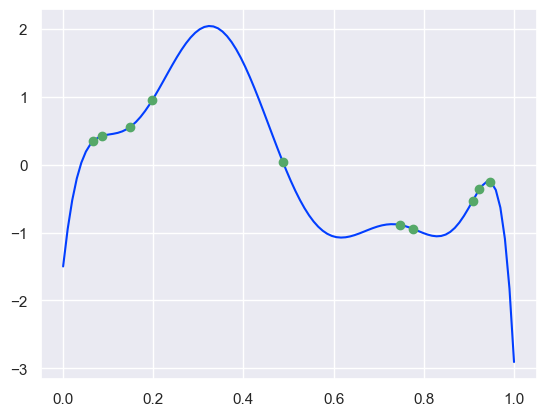

In [39]:
plt.plot(x_test, list(map(lambda x: linear(x, optimal_weights(x_train, y_train, 9)), x_test)), '-')
plt.plot(x_train, y_train, 'og')

## 2) Regularization

### 2.1) Error function

Implement the cost function `err_regularization` that takes into account the regularization term, as given in the equation on slide 16 of Lecture 3. The function should take `weights`, `inputs`, `targets` and `l` (lambda regularization term) as input parameters and compute sum-of-squared error with weight regularization.

In [40]:
def err_regularization(weights, inputs, targets, l):
    # 1) Usar la función linear para predecir cada elemento de inputs.
    x_preds = [] # crear una lista
    for x in inputs:
        prediction = linear(x, weights)
        x_preds.append(prediction)
    
    x_preds = np.array(x_preds)
        
        # 2) Calcular la diferencia entre cada predicción y su target, y elevar al cuadrado
    sqrd_diff = (x_preds - targets)**2
        # 3) Sumarlas y aplica el 1/2
    err_func = (1/2) * np.sum(sqrd_diff)
    err_reg = err_func + (l/2)*(np.linalg.norm(weights)**2) # calculamos la norma al cuadrado del vector de pesos
    return err_reg

Write the `erms_regularization` function which is regularization version of a root mean squared error (slide 12 in lecture 3)

In [41]:
def erms_regularization(weights, inputs, targets, l):
    err_reg = err_regularization(weights, inputs, targets, l)
    erms_reg = np.sqrt((2*err_reg)/len(targets))
    return erms_reg

### 2.2) Optimization

Create a function below that obtains `optimal_weights_regularization` by implementing the optimization solution of the regularized problem as given in slide 16 of Lecture 3. The function takes the following parameters: `inputs`, `targets`, `M` (number of weights) and `l` (regularization term) as parameters and returns optimal weights for the given set of training data.

In [42]:
def optimal_weights_regularization(inputs, targets, M, l):
    N = len(inputs)
    X = np.vander(inputs, N=M + 1, increasing=True) # it produces the exact design matrix, increasing the powers after each element in the row
    p1 = l*np.eye(M+1) # l*I
    p2 = np.dot(np.transpose(X), X) # X^T * X
    p3 = np.linalg.inv(p1 + p2) # (l*I + X^T*X)^-1
    p4 = np.dot(np.transpose(X), targets) # X^T * t
    opt_weights_reg = np.dot(p3, p4)
    return opt_weights_reg

### 2.3) Test with regularization

Go through the following code and try to understand its functionality. After that, run the code and interpret the resulting figures.

(0.0, 1.05)

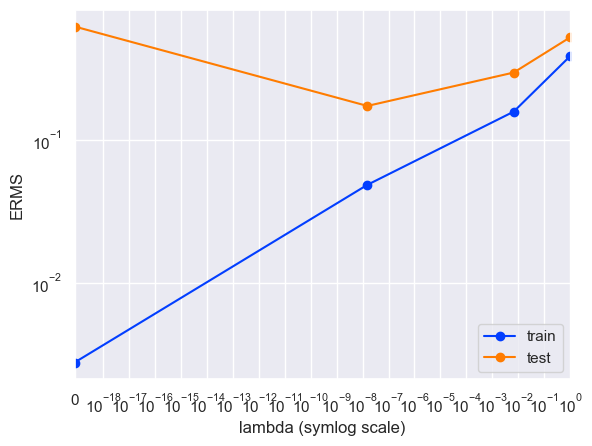

In [43]:
def test_all_regularization(ls, M, x_train, y_train, x_test, y_test):

    results_train = []
    results_test = []
    all_weights = []

    for l in ls:
        weights = optimal_weights_regularization(x_train, y_train, M, l)
        all_weights.append(weights)
        # Both train and test curves report the UNPENALIZED RMS error
        # E_RMS = sqrt(2 E(w*)/N) (L3 slide 12), as in PRML Fig 1.8.
        # Regularization only biases the fit; its penalty term is not part of the
        # reported error, otherwise the U-shaped generalization curve is hidden.
        error_train = erms(weights, x_train, y_train)
        error_test = erms(weights, x_test, y_test)
        results_train.append(error_train)
        results_test.append(error_test)
    return results_train, results_test, all_weights

ls = [0, exp(-18), exp(-5), exp(0)]

r_tr_r, r_tt_r, all_weights_r = test_all_regularization(ls, 9, x_train, y_train, x_test, y_test)

plt.plot(ls, r_tr_r, '-o', label='train')
plt.plot(ls, r_tt_r, '-o', label='test')
plt.xlabel('lambda (symlog scale)')
plt.ylabel('ERMS')
plt.legend()
plt.yscale('log')
plt.xscale('symlog', linthresh=1e-18)
plt.xlim(left=0)

##### Weights for `M=9` with regularization terms `0`, `exp(-18)`, `exp(-5)`, `exp(0)`

In [44]:
print(pd.DataFrame(np.transpose(all_weights_r)))

               0           1         2         3
0      -1.499639    0.699011  0.503543  0.328543
1      61.350069  -11.795682  0.743539 -0.389393
2    -716.570195  121.043844 -2.425527 -0.353466
3    3503.407049 -335.150177 -1.908122 -0.232935
4   -3866.782038  217.987061 -0.795824 -0.127092
5  -21524.041629  178.622534  0.106829 -0.046211
6   81644.465542  -87.722824  0.719266  0.013218
7 -117566.329605 -148.839187  1.096707  0.055948
8   79249.048768  -12.387887  1.302133  0.085993
9  -20785.960092   78.207422  1.385740  0.106489


In [45]:
def plot_by_lambda(l):
    plt.plot(x_test, y_test, '-r')
    plt.plot(x_test, list(map(lambda x: linear(x, optimal_weights_regularization(x_train, y_train, 9, l)), x_test)), '-')
    plt.plot(x_train, y_train, 'og')

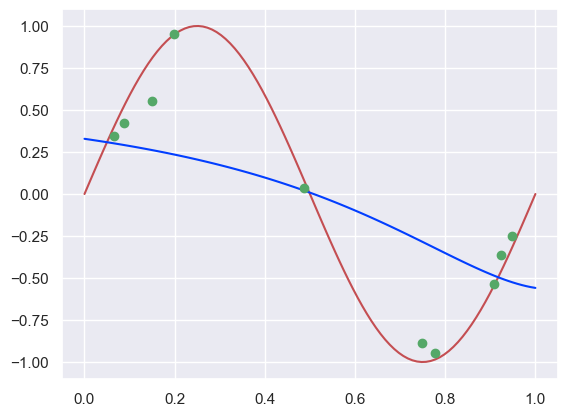

In [46]:
plot_by_lambda(exp(0))

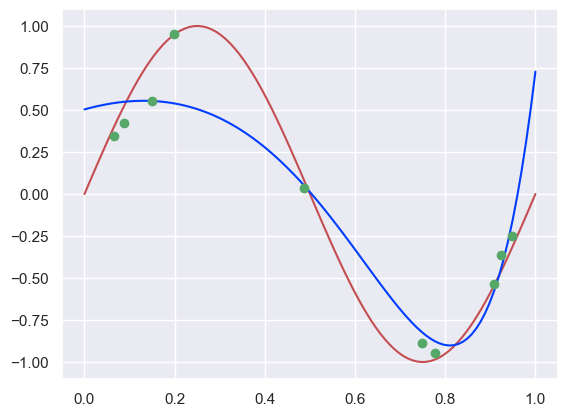

In [47]:
plot_by_lambda(exp(-5))

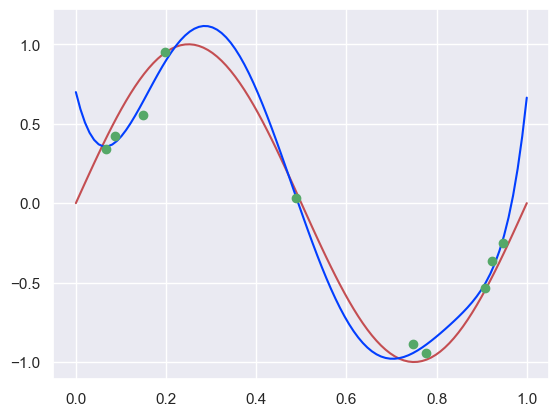

In [48]:
plot_by_lambda(exp(-18))

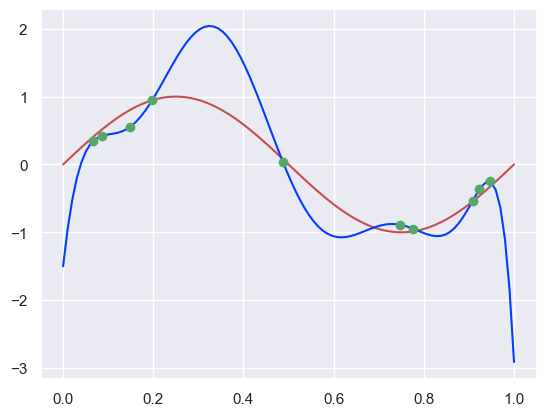

In [49]:
plot_by_lambda(0)

## 3) Model Selection

### 3.1) Cross-validation

Write a function called 'create_cross_validation_sets' that:

Takes as input:

S: the number of folds (sets) for cross-validation,

x_train, y_train: the training data points.

Returns a Python list of length S. Each element of this list must itself be a list or tuple of the form:

[x_sub_train, y_sub_train, x_validation, y_validation]

where:

x_validation, y_validation is one fold of the training data.

x_sub_train, y_sub_train is the remaining training data (the other S-1 folds).

Together, all validation folds should cover the entire training set without overlap.

Name the returned list as 'sets'.

Hint: Refer to the figure in slide 20 of Lecture 3 to see how cross-validation folds are constructed.

In [50]:
def create_cross_validation_sets(S, x_train, y_train): # it returns a list of lists
    sets = []
    N = len(x_train) # total number of points, size of the array
    x_folds = np.array_split(x_train, S) # it splits the data in S folds/chunks
    y_folds = np.array_split(y_train, S)
    for i in range(S):
        x_val = x_folds[i] # the i'th fold
        y_val = y_folds[i]
        x_other_folds = x_folds[:i] + x_folds[i + 1:] # we combine the folds before and after the i'th fold
        y_other_folds = y_folds[:i] + y_folds[i + 1:]
        x_sub = np.concatenate(x_other_folds)
        y_sub = np.concatenate(y_other_folds)
        sets.append([x_sub, y_sub, x_val, y_val])
        
    return sets

Implement the function 'best_model' that searches for the best polynomial model order and regularization parameter using S-fold cross-validation.

The function should loop over all integers M between start_M and end_M (inclusive).

For each M, also loop over all values of ls (a list of candidate regularization parameters).

For each combination (M, λ), perform S-fold cross-validation (as described in the lecture):

1. Use the S folds passed in through the `sets` argument (they are built beforehand with 'create_cross_validation_sets' — see the cell below).

For each fold:

2. Fit the model with order M and regularization λ on the sub-train data.

3. Compute the ERMS (without regularization term) on the validation fold.

4. Average the validation ERMS across all S folds.

5. Keep track of the (M, λ) pair that achieves the lowest mean validation ERMS.

The function must return: (best_M, best_lambda, best_mean_val_erms)

**Note:** for M ≥ N_sub and l=0 the design-matrix Gram matrix is rank-deficient and cannot be inverted. Regularization (l > 0) makes it invertible. You may wish to skip or handle the l=0 case gracefully (e.g. append `np.inf` to the fold errors on `np.linalg.LinAlgError`).

M = 3 lambda = 0 CV ERMS = 0.0817533295916454


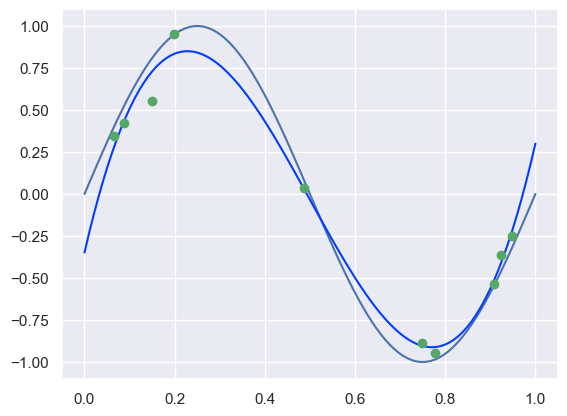

In [51]:
def best_model(start_M, end_M, ls, sets):
    """
    Grid-search over M in [start_M, end_M] and lambdas in ls using the
    provided cross-validation 'sets' (list of (x_sub, y_sub, x_val, y_val)).
    
    Returns:
        (best_M, best_lambda, best_mean_val_erms)
    """

    best_M = None
    best_lambda = None
    best_mean = np.inf
    
    for M in range(start_M, end_M + 1):
        for l in ls:
            results_val = []

            for s in sets:
                # [x_sub_train, y_sub_train, x_validation, y_validation]
                x_train, y_train, x_val, y_val = s 
                try:
                    weights = optimal_weights_regularization(
                            x_train, y_train, M, l
                    )
                    error_val = erms(weights, x_val, y_val)
                    results_val.append(error_val)
                
                except np.linalg.LinAlgError:
                    results_val.append(np.inf)
                    break
            
            candidate_mean = np.mean(results_val) 
            if (candidate_mean < best_mean):
                best_mean = candidate_mean
                best_lambda = l
                best_M = M
                       
    
    return best_M, best_lambda, best_mean


# Use the ORIGINAL training set to build CV folds
sets = create_cross_validation_sets(10, x_train, y_train)

M, l, r = best_model(0, 9, [0, exp(-18), exp(-5), exp(0)], sets)
print('M =', M, 'lambda =', l, 'CV ERMS =', r)

# Retrain on full training set with the chosen hyperparams, then plot/predict
plt.plot(x_test, y_test, '-b')
plt.plot(x_test, [linear(x, optimal_weights_regularization(x_train, y_train, M, l)) for x in x_test], '-')
plt.plot(x_train, y_train, 'og')

## 4) Bayesian curve fitting (Optional)

This exercise is optional. It requires an understanding of Section 1.2.6 of the textbook, which builds on the Bayesian-inference reading assignment (Sections 1.2.4–1.2.5) given at the end of Lecture 4. The function below `phi` takes `x` (data point) and `M` (number of weights) as arguments and returns a vector of powers of `x` from `0` to `M`

In [52]:
def phi(x, M):
    pass

`S` takes `alpha`, `beta`, `x` (all data points), and `M` as arguments and returns a matrix `S` that is used to compute `mean` and `variance`

In [53]:
def S(alpha, beta, x, M):
    pass

`mean` takes `alpha`, `beta`, `x_star` (new point), `x` (all data points), `t` (target values), and `M` and computes mean for the Gaussian distribution

In [54]:
def mean(alpha, beta, x_star, x, t, M):
    pass

`variance` takes `alpha`, `beta`, `x_star` (new point), `x` (all data points), `t` (target values), and `M` and computes variance for the Gaussian distribution

In [55]:
def variance(alpha, beta, x_star, x, t, M):
    # Hint: the predictive variance has two ADDITIVE terms (PRML eq. 1.71):
    #   s^2(x*) = beta^{-1}  +  phi(x*)^T S_N phi(x*)
    # The beta^{-1} term is the data-noise floor; phi(...)^T S phi(...) is
    # the model uncertainty. Do NOT multiply them together.
    pass

### 4.1) Display results

TypeError: loop of ufunc does not support argument 0 of type NoneType which has no callable sqrt method

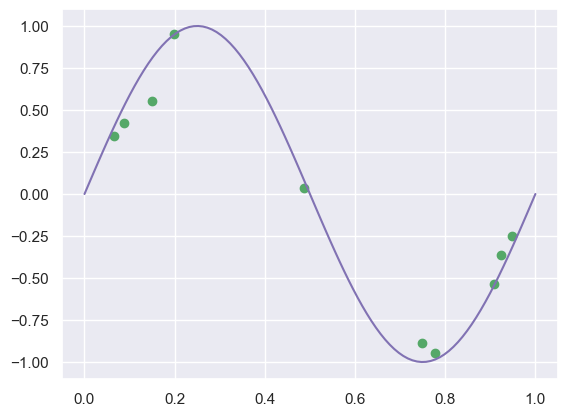

In [56]:
# Hyperparameters from PRML §1.2.6 / Figure 1.17: alpha = 5e-3, beta = 11.1
alpha = 0.005
beta = 11.1
M = 9

means = np.array(list(map(lambda x: mean(alpha, beta, x, x_train, y_train, M), x_test)))
variances = np.array(list(map(lambda x: variance(alpha, beta, x, x_train, y_train, M), x_test)))

plt.plot(x_train, y_train, 'og')
plt.plot(x_test, y_test, '-m')
plt.plot(x_test, means, '-b')
# Shade the mean ±1 predictive STANDARD DEVIATION (PRML Fig 1.17).
# variance has units of t^2, so take the square root before plotting.
stds = np.sqrt(variances)
plt.fill_between(x_test, means + stds, means - stds, color='red', alpha=0.3)